# **Unemployment of India: Data Analysis**

## **Introduction**
---
This project looks at unemployment in India, focusing on how it differs across regions. It explores key factors like job availability and how many people are actively looking for work. The goal is to understand these trends better and help find solutions to reduce unemployment in India.

### **Descriptions about Unemployment of India dataset:**
---

1. **Region** - The state or region name where unemployment data is recorded.

2. **Date** - The date or month/year when the data was collected.

3. **Frequency** - Shows how often the data is recorded (for example: Monthly, Quarterly).

4. **Estimated Unemployment Rate (%)** - The percentage of people who are unemployed but actively looking for jobs.

5. **Estimated Employed** - The total number of people who currently have jobs in that region.

6. **Estimated Labour Participation Rate (%)** - The percentage of working-age people who are working or looking for work.

7. **Area** - Indicates whether the data is from a Rural or Urban area.

In [ ]:
# import libraries for data analysis

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

In [ ]:
warnings.filterwarnings("ignore")

In [ ]:
from google.colab import drive     # connect google drive with colab
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
df = pd.read_csv("/content/drive/MyDrive/Unemployment in India.csv")       # load dataset

In [ ]:
df

,Region,Date,Frequency,Estimated Unemployment Rate (%),Estimated Employed,Estimated Labour Participation Rate (%),Area
0,Andhra Pradesh,31-05-2019,Monthly,3.65,11999139.0,43.24,Rural
1,Andhra Pradesh,30-06-2019,Monthly,3.05,11755881.0,42.05,Rural
2,Andhra Pradesh,31-07-2019,Monthly,3.75,12086707.0,43.50,Rural
3,Andhra Pradesh,31-08-2019,Monthly,3.32,12285693.0,43.97,Rural
4,Andhra Pradesh,30-09-2019,Monthly,5.17,12256762.0,44.68,Rural
...,...,...,...,...,...,...,...
763,NaN,NaN,NaN,NaN,NaN,NaN,NaN
764,NaN,NaN,NaN,NaN,NaN,NaN,NaN
765,NaN,NaN,NaN,NaN,NaN,NaN,NaN
766,NaN,NaN,NaN,NaN,NaN,NaN,NaN


### **Data Understanding**
---
####Check the dataset structure, columns, and basic statistics; identify missing values.

In [ ]:
df.info()   # display columns information like: count of null values, data type

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 7 columns):
 #   Column                                    Non-Null Count  Dtype  
---  ------                                    --------------  -----  
 0   Region                                    740 non-null    object 
 1    Date                                     740 non-null    object 
 2    Frequency                                740 non-null    object 
 3    Estimated Unemployment Rate (%)          740 non-null    float64
 4    Estimated Employed                       740 non-null    float64
 5    Estimated Labour Participation Rate (%)  740 non-null    float64
 6   Area                                      740 non-null    object 
dtypes: float64(3), object(4)
memory usage: 42.1+ KB


In [ ]:
df.columns    # display all columns name

Index(['Region', ' Date', ' Frequency', ' Estimated Unemployment Rate (%)',
       ' Estimated Employed', ' Estimated Labour Participation Rate (%)',
       'Area'],
      dtype='object')

In [ ]:
df.shape    # display rows and columns number

(768, 7)

In [ ]:
# modify columns name
df.columns = ['Region', 'Date', 'Frequency', 'Estimated Unemployment Rate',
              'Estimated Employed', 'Estimated Labour Participation Rate',
              'Area']

In [ ]:
df.isnull().sum()   # sum of null values

,0
Region,28
Date,28
Frequency,28
Estimated Unemployment Rate,28
Estimated Employed,28
Estimated Labour Participation Rate,28
Area,28


### **Data Cleaning**
---
####Handle missing data, transform data types, and manage outliers.

In [ ]:
cleaned_df = df.dropna()    # dropping null values

In [ ]:
print((cleaned_df.isnull().sum() / len(cleaned_df)) * 100)    # check percentage of null value

Region                                 0.0
Date                                   0.0
Frequency                              0.0
Estimated Unemployment Rate            0.0
Estimated Employed                     0.0
Estimated Labour Participation Rate    0.0
Area                                   0.0
dtype: float64


In [ ]:
cleaned_df["Date"] = pd.to_datetime(cleaned_df["Date"], dayfirst = True, errors="coerce")    # convert datetime

In [ ]:
# cleaned_df.loc[:, "Date"] = pd.to_datetime(cleaned_df["Date"], dayfirst=True, errors="coerce")

In [ ]:
cleaned_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 740 entries, 0 to 753
Data columns (total 7 columns):
 #   Column                               Non-Null Count  Dtype         
---  ------                               --------------  -----         
 0   Region                               740 non-null    object        
 1   Date                                 740 non-null    datetime64[ns]
 2   Frequency                            740 non-null    object        
 3   Estimated Unemployment Rate          740 non-null    float64       
 4   Estimated Employed                   740 non-null    float64       
 5   Estimated Labour Participation Rate  740 non-null    float64       
 6   Area                                 740 non-null    object        
dtypes: datetime64[ns](1), float64(3), object(3)
memory usage: 46.2+ KB


In [ ]:
cleaned_df.loc[:, "Frequency"] = cleaned_df["Frequency"].astype("category")   # convert frequency column to category

In [ ]:
cleaned_df.head()

,Region,Date,Frequency,Estimated Unemployment Rate,Estimated Employed,Estimated Labour Participation Rate,Area
0,Andhra Pradesh,2019-05-31,Monthly,3.65,11999139.0,43.24,Rural
1,Andhra Pradesh,2019-06-30,Monthly,3.05,11755881.0,42.05,Rural
2,Andhra Pradesh,2019-07-31,Monthly,3.75,12086707.0,43.50,Rural
3,Andhra Pradesh,2019-08-31,Monthly,3.32,12285693.0,43.97,Rural
4,Andhra Pradesh,2019-09-30,Monthly,5.17,12256762.0,44.68,Rural


In [ ]:
cleaned_df.loc[:, "Month"] = cleaned_df["Date"].dt.month_name()   # extract month name from date column

In [ ]:
cleaned_df.head()

,Region,Date,Frequency,Estimated Unemployment Rate,Estimated Employed,Estimated Labour Participation Rate,Area,Month
0,Andhra Pradesh,2019-05-31,Monthly,3.65,11999139.0,43.24,Rural,May
1,Andhra Pradesh,2019-06-30,Monthly,3.05,11755881.0,42.05,Rural,June
2,Andhra Pradesh,2019-07-31,Monthly,3.75,12086707.0,43.50,Rural,July
3,Andhra Pradesh,2019-08-31,Monthly,3.32,12285693.0,43.97,Rural,August
4,Andhra Pradesh,2019-09-30,Monthly,5.17,12256762.0,44.68,Rural,September


In [ ]:
cleaned_df.loc[:, "Year"] = cleaned_df["Date"].dt.year    # extract year from date column

In [ ]:
cleaned_df.head()

,Region,Date,Frequency,Estimated Unemployment Rate,Estimated Employed,Estimated Labour Participation Rate,Area,Month,Year
0,Andhra Pradesh,2019-05-31,Monthly,3.65,11999139.0,43.24,Rural,May,2019
1,Andhra Pradesh,2019-06-30,Monthly,3.05,11755881.0,42.05,Rural,June,2019
2,Andhra Pradesh,2019-07-31,Monthly,3.75,12086707.0,43.50,Rural,July,2019
3,Andhra Pradesh,2019-08-31,Monthly,3.32,12285693.0,43.97,Rural,August,2019
4,Andhra Pradesh,2019-09-30,Monthly,5.17,12256762.0,44.68,Rural,September,2019


In [ ]:
cleaned_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 740 entries, 0 to 753
Data columns (total 9 columns):
 #   Column                               Non-Null Count  Dtype         
---  ------                               --------------  -----         
 0   Region                               740 non-null    object        
 1   Date                                 740 non-null    datetime64[ns]
 2   Frequency                            740 non-null    object        
 3   Estimated Unemployment Rate          740 non-null    float64       
 4   Estimated Employed                   740 non-null    float64       
 5   Estimated Labour Participation Rate  740 non-null    float64       
 6   Area                                 740 non-null    object        
 7   Month                                740 non-null    object        
 8   Year                                 740 non-null    int32         
dtypes: datetime64[ns](1), float64(3), int32(1), object(4)
memory usage: 54.9+ KB


### **Exploratory Data Analysis (EDA)**
---
####Analyze summary statistics, correlations, and identify trends or issues.

In [ ]:
cleaned_df.describe()      # statstical table representation

,Estimated Unemployment Rate (%),Estimated Employed,Estimated Labour Participation Rate (%)
count,740.000000,7.400000e+02,740.000000
mean,11.787946,7.204460e+06,42.630122
std,10.721298,8.087988e+06,8.111094
min,0.000000,4.942000e+04,13.330000
25%,4.657500,1.190404e+06,38.062500
50%,8.350000,4.744178e+06,41.160000
75%,15.887500,1.127549e+07,45.505000
max,76.740000,4.577751e+07,72.570000


In [ ]:
corre = df.corr(numeric_only = True)   # correlation table

In [ ]:
corre

,Estimated Unemployment Rate,Estimated Employed,Estimated Labour Participation Rate
Estimated Unemployment Rate,1.000000,-0.222876,0.002558
Estimated Employed,-0.222876,1.000000,0.011300
Estimated Labour Participation Rate,0.002558,0.011300,1.000000


### **Data Visualization**
---

####Create charts (e.g., bar, line, heatmap, box plots) to visualize key trends and patterns.

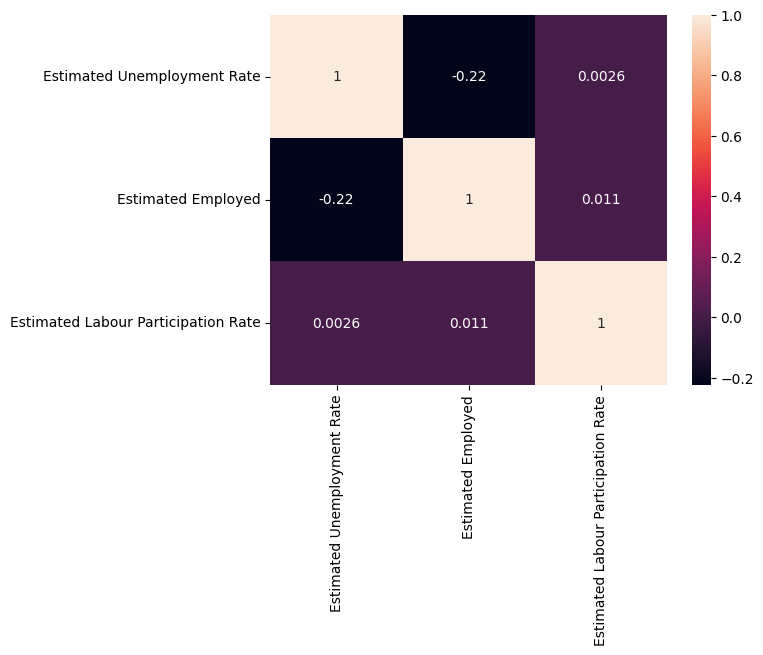

In [ ]:
# Plotting heatmap

sns.heatmap(corre, annot = True)   # describe correlation using heatmap
plt.show()

**Insights:**

1. **Estimated Unemployment vs Estimated Employment:**

    There is a negative correlation (-0.22), meaning when unemployment increases, employment tends to decrease.

2. **Estimated Unemployment vs Estimated Labour Participation**:

    The correlation is almost zero (0.0026), showing almost no relationship between them.

3. **Estimated Employment vs Estimated Labour Participation**:

    There is a very weak positive correlation (0.011) between employment and labour participation rate.

4. **Self-Correlation**:

    Each variable has a perfect correlation (1.0) with itself on the heatmap diagonal.

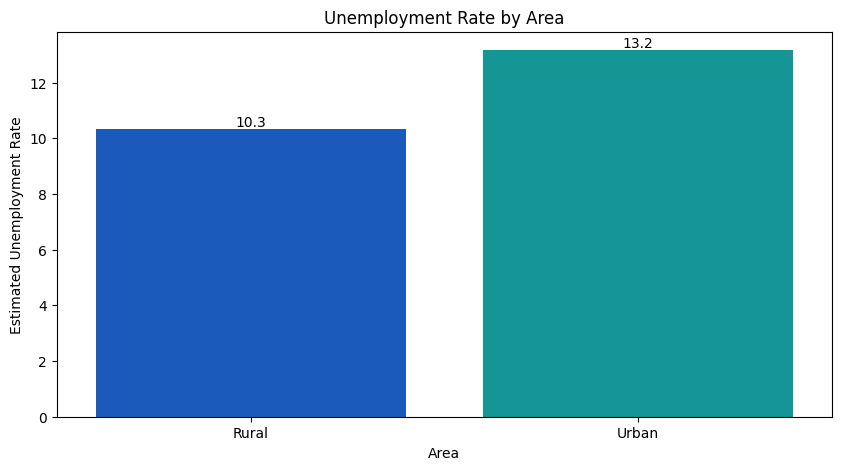

In [ ]:
# Plotting bar plot

plt.figure(figsize = (10, 5))    # set size of graph (width, height)

ax= sns.barplot(x = "Area", y = "Estimated Unemployment Rate", data = cleaned_df, palette = "winter", errorbar = None)
ax.bar_label(ax.containers[0], fmt='%1.1f')   # name of bar label
ax.bar_label(ax.containers[1], fmt='%1.1f')

plt.title("Unemployment Rate by Area")    # set title of graph
plt.show()

**Insights:**
1. Highest average unemployment rate in urban area and lowest average rate in rural area

2. Average estimated unemployment rate by area in **Rural** value is **10.3** and **Urban** value is **13.2**

3. The visible gap between rural and urban area value is **2.9**

In [ ]:
region_unemp = cleaned_df.groupby(["Region", "Area"])["Estimated Unemployment Rate"].mean().sort_values(ascending= False).reset_index()   # calculate average estimated unemployment rate

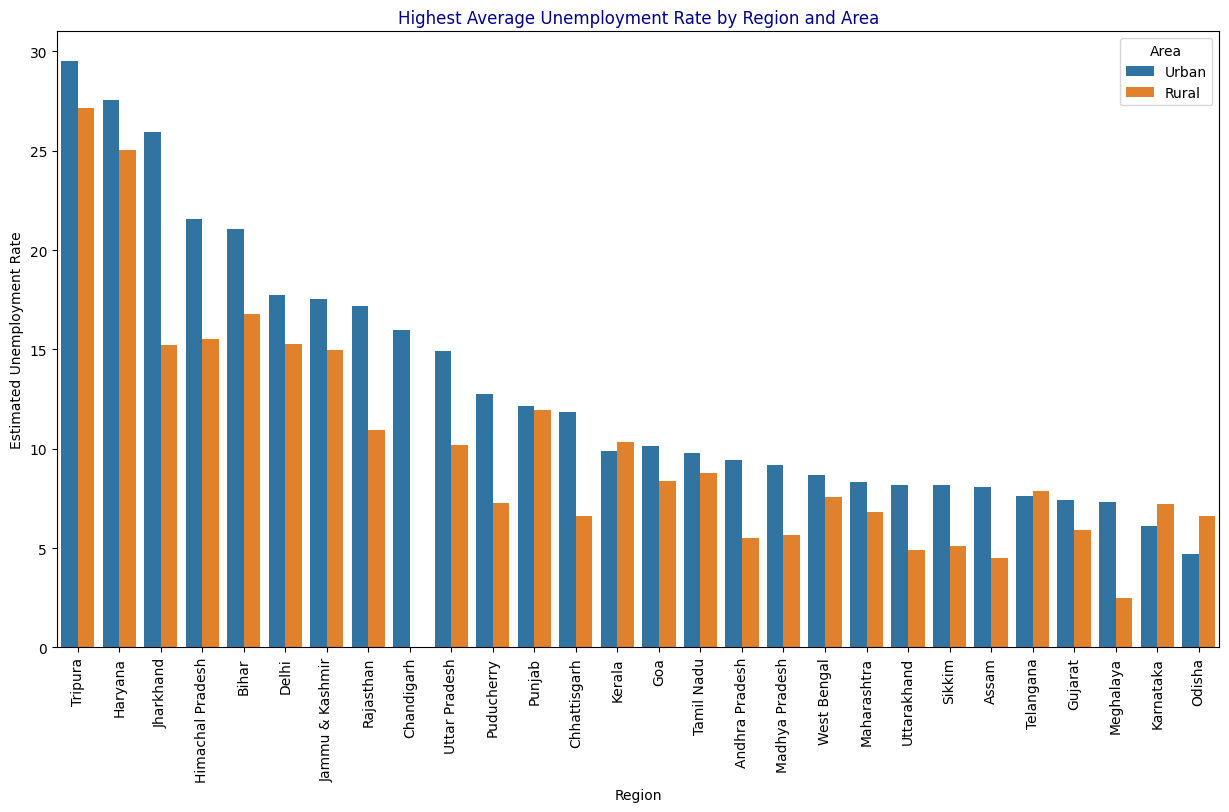

In [ ]:
# Plotting bar plot

plt.figure(figsize = (15, 8))

sns.barplot(x = "Region", y = "Estimated Unemployment Rate", hue = "Area", data = region_unemp, errorbar= None)

plt.xticks(rotation = 90)   # rotation of x-axis label

plt.title("Highest Average Unemployment Rate by Region and Area", color = "darkblue")
plt.show()

**Insights:**

1. **Tripura** has the highest unemployment rate in both urban and rural areas.

2. Almost every state, the urban unemployment rate is higher than the rural unemployment rate.

3. **Odisha** and **Karnataka** has the lowest unemployment rate.

4. The chart shows a clear downward trend in unemployment as you move from **Tripura** to **Odisha**.


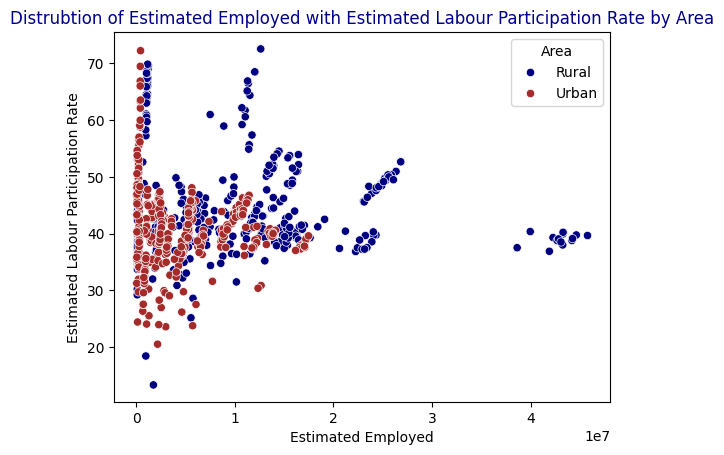

In [ ]:
# Plotting scatter plot

sns.scatterplot(
    x = "Estimated Employed",
    y = "Estimated Labour Participation Rate",
    data = cleaned_df,
    hue = "Area",
    palette = ["navy","brown"]    # change colour of data points inside graph
)
plt.title("Distrubtion of Estimated Employed with Estimated Labour Participation Rate by Area", color = "darkblue")
plt.show()

**Insights:**

1. **Urban area** data points (Blue) are broader range of total employment.

2. **Rural area** data points (Red) are heavily at lower employment volume levels.

3. The highest average rate in rural area as compare to urban area.

4. There is no clear relationship between the number of people employed and the participation rate.

In [ ]:
area_data = cleaned_df.groupby("Area")["Estimated Unemployment Rate"].mean()    # calculate average unemployment rate by area

In [ ]:
area_data

,Estimated Unemployment Rate
Area,
Rural,10.324791
Urban,13.166614


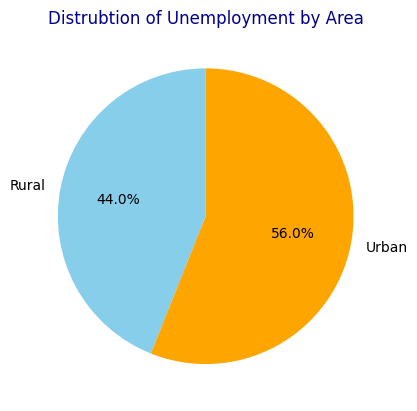

In [ ]:
# Plotting pie plot
plt.figure(figsize= (5, 5))

plt.pie(
    area_data,
    labels = area_data.index,
    autopct = "%1.1f%%",
    startangle = 90,
    colors = ["skyblue", "orange"]    # change color of pie chart
    )

plt.title("Distrubtion of Unemployment by Area", color = "darkblue")
plt.show()

**Insights:**

1. Urban area (56%) highest distrubtion of unemployment rate.

2. Rural area (44%) lowest distrubtion of unemployment rate.

3. The (12%) gap between urban and rural area is clear show.

4. More people are unemployed in urban areas compared to rural areas.

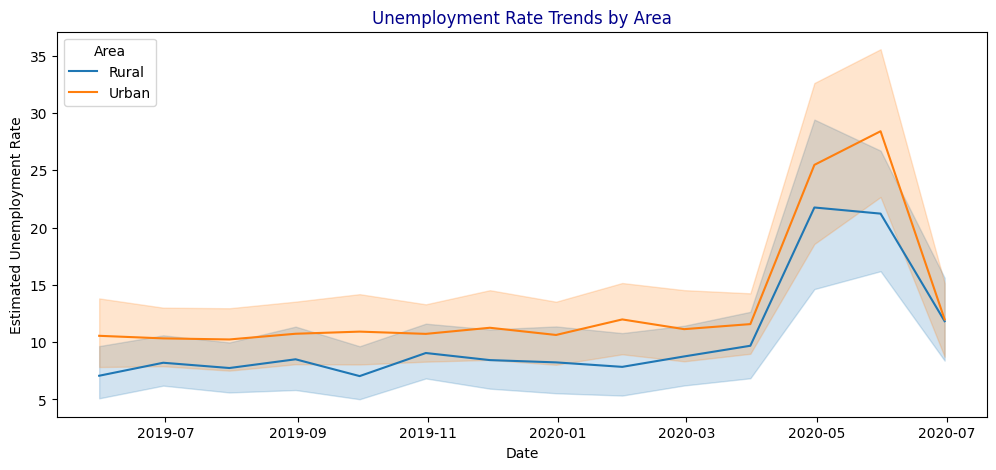

In [ ]:
# Plotting line plot

plt.figure(figsize = (12, 5))

sns.lineplot(
    x = "Date",
    y = "Estimated Unemployment Rate",
    data = cleaned_df,
    hue = "Area"
)
plt.title("Unemployment Rate Trends by Area", color = "darkblue")
plt.show()

**Insights:**

1. Both Urban and Rural unemployment rates stable until early 2020.

2. The huge spike of uraban and rural area unemployment starting in April 2020.  

3. Urban unemployment remained consistently higher than rural rates throughout the entire period.

4. Rapid Recovery in both sectors show a very sharp decline and recovery trend by July 2020.

In [ ]:
state = cleaned_df["Region"].unique()[:6]   # remove duplicate region name and combine into single region name

In [ ]:
state

array(['Andhra Pradesh', 'Assam', 'Bihar', 'Chhattisgarh', 'Delhi', 'Goa'],
      dtype=object)

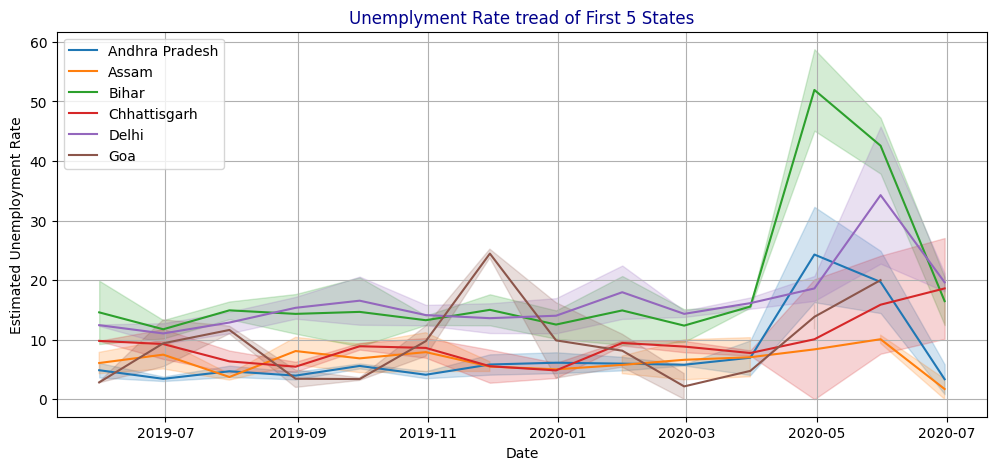

In [ ]:
plt.figure(figsize = (12, 5))   # set the size of graph (width, height)

for s in state:   # use loop for disply state one by one
  data = cleaned_df[cleaned_df["Region"] == s]
  sns.lineplot(x = "Date", y = "Estimated Unemployment Rate", data = data, label = s)

plt.title("Unemplyment Rate tread of First 5 States", color = "darkblue")
plt.xlabel("Date")
plt.ylabel("Estimated Unemployment Rate")

plt.grid(True)
plt.legend()

plt.show()

**Insights:**

1. Unemployment rates in most states were stable until early 2020.

2. Bihar had the highest unemployment spike, crossing **50%** in **May 2020**.

3. Assam had the lowest and most stable unemployment during the whole period from **July 2019 to July 2020**.

4. Most states saw a sharp rise in unemployment in early 2020 (second quarter from **March 2020 to May 2020**).

5. The Phase from **July 2020**, unemployment started decreasing in all states.


In [ ]:
df_year = cleaned_df.groupby("Year")["Estimated Unemployment Rate"].count().sort_values(ascending = False) # count estimated unemployment rate

In [ ]:
df_year

,Estimated Unemployment Rate
Year,
2019,430
2020,310


In [ ]:
df_year_percent = (df_year / df_year.sum()) * 100     # calculate percentage of unemployment rate by year

In [ ]:
df_year_percent

,Estimated Unemployment Rate
Year,
2019,58.108108
2020,41.891892


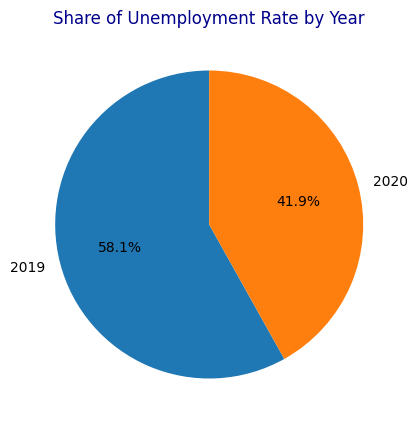

In [ ]:
# Plotting pie plot

plt.figure(figsize= (5, 5))

plt.pie(
    df_year.values,
    labels = df_year.index,
    autopct = "%1.1f%%",
    startangle = 90
    )

plt.title("Share of Unemployment Rate by Year", color = "darkblue")
plt.show()

**Insight:**

1. The distubtion share of unemployment rate was (58.1%) highest in 2019 and (41.9%) lower in 2020.

2. The difference between the two years is about (16%) gap in year 2020 and 2019.

3. Overall the chart shows 2019 more to the highest unemployment rates than 2020.

In [ ]:
top10_region = cleaned_df.groupby("Region")["Estimated Unemployment Rate"].mean() \
              .sort_values(ascending= False).head(10)    # calculate average unemployment rate

In [ ]:
top10_region

,Estimated Unemployment Rate
Region,
Tripura,28.350357
Haryana,26.283214
Jharkhand,20.585000
Bihar,18.918214
Himachal Pradesh,18.540357
Delhi,16.495357
Jammu & Kashmir,16.188571
Chandigarh,15.991667
Rajasthan,14.058214


**Note:**

- **Index** = Region names

- **Values** = Unemployment rate

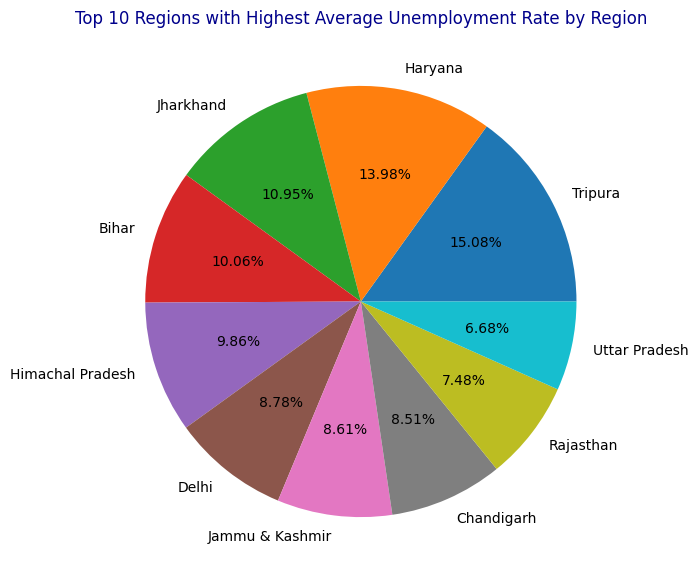

In [ ]:
# Plotting pie chart

plt.figure(figsize = (7, 7))

plt.pie(top10_region, labels = top10_region.index ,autopct = "%.2f%%")

plt.title("Top 10 Regions with Highest Average Unemployment Rate by Region", color = "darkblue")
plt.show()

**Insight:**

1. The highest distrubtion unemployment rate share state in **Tripura (15.08%)** and the  highest distrubtion unemployment rate share state in **Uttar Pradesh (6.68%)**.

2. Unemployment is unevenly distributed, with **Tripura** and **Haryana** having the highest shares.

3. Mid-level contributors such as **Bihar (10.06%)** and **Himachal Pradesh (9.86%)** also represent a significant portion of unemployment.

4. Most states fall within a narrow range (7%–11%), suggesting unemployment levels are relatively similar across many regions.

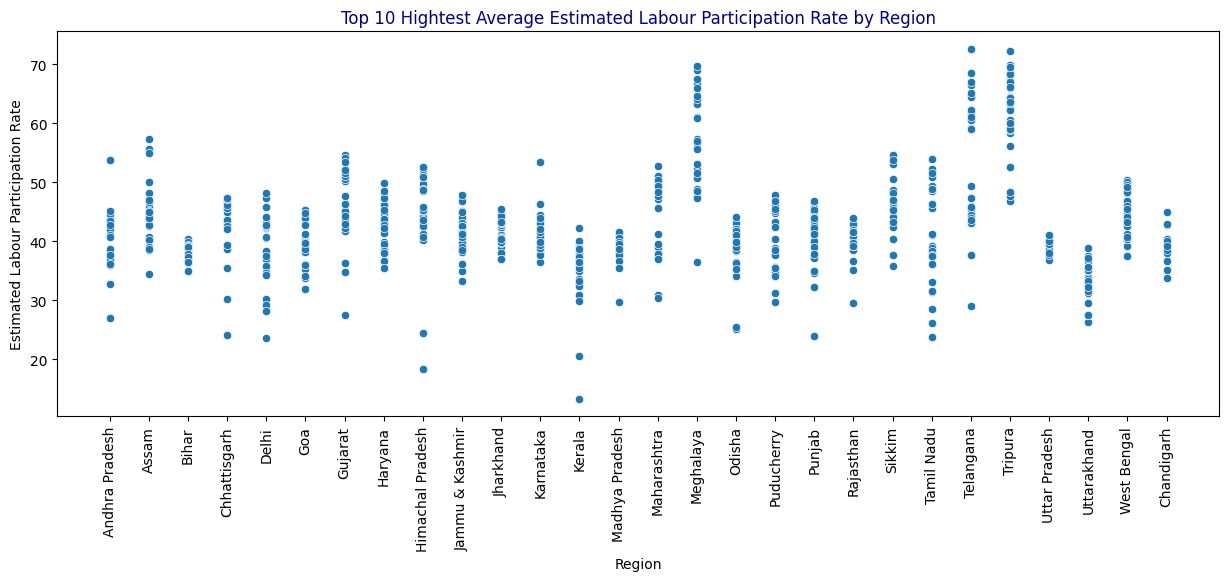

In [ ]:
# Plotting scatter plot

plt.figure(figsize = (15, 5))
sns.scatterplot(x = "Region", y = "Estimated Labour Participation Rate", data = cleaned_df)

plt.title("Top 10 Hightest Average Estimated Labour Participation Rate by Region", color = "darkblue")
plt.xticks(rotation = 90)

plt.show()

**Insight:**

1. The higest labour participation rate by region in **Telangana,  Tripura (70% above) and Meghalaya (60% - 70%)**

2. Labour participation varies significantly across states, with **Tripura and Telangana** showing the highest levels.

3. **Kerala and Uttar Pradesh** show lower participation values, sometimes dropping below **35%**.

4. The labour participation rate varies widely across states, ranging roughly from 15% to over **70%**.

In [ ]:
df_month = cleaned_df.groupby("Month")["Estimated Unemployment Rate"].mean()  # Combine similar Month into single Month name

In [ ]:
df_month.sort_values(ascending= False)

,Estimated Unemployment Rate
Month,
April,23.641569
May,16.646190
March,10.700577
June,10.553462
February,9.964717
January,9.950755
October,9.900909
November,9.868364
August,9.637925


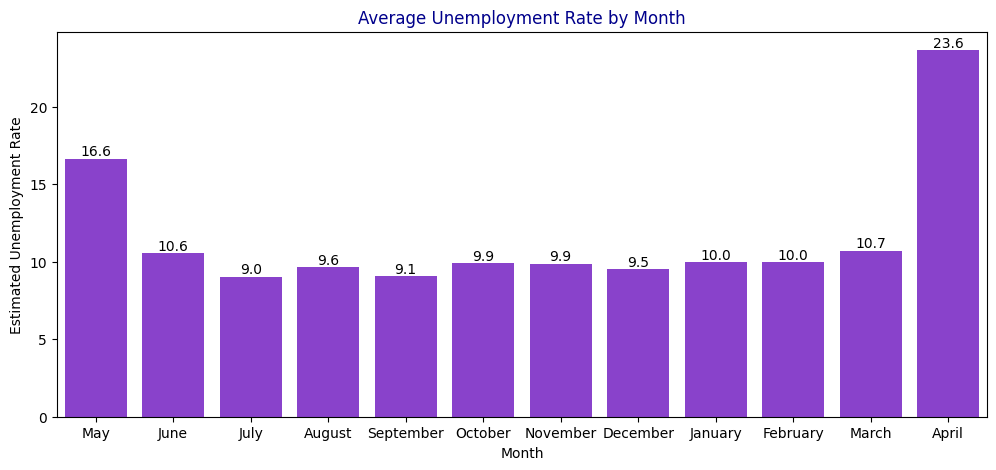

In [ ]:
# Bar Plot by Seaborn
plt.figure(figsize = (12, 5))

ax = sns.barplot(x = "Month", y = "Estimated Unemployment Rate", data = cleaned_df, color = "blueviolet", errorbar = None)
ax.bar_label(ax.containers[0], fmt ='%1.1f')

plt.title("Average Unemployment Rate by Month", color ="darkblue")

plt.show()

**Insight:**

1. The average unemployment rate was highest in **April** and second highest in **May**.

2. The lowest unemployment rate at **July**.

3. Unemployment remained mostly stable between **July to February**.

4. Unemployment started rising again in **March** before reaching the peak in April.

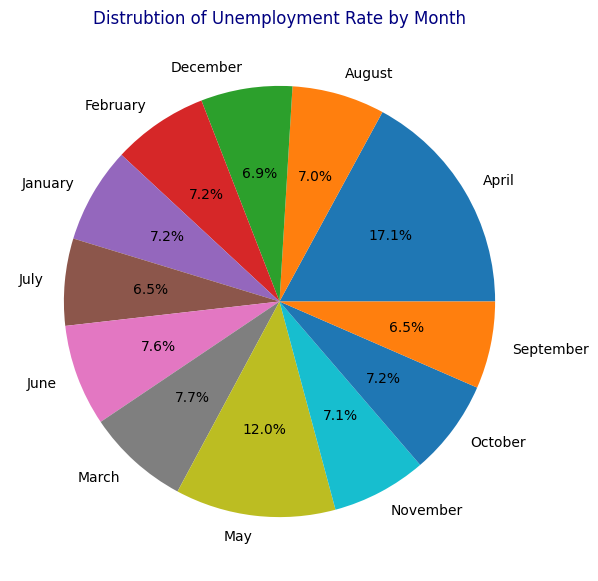

In [ ]:
plt.figure(figsize = (7, 7))
plt.pie(df_month, labels = df_month.index, autopct = "%1.1f%%")
plt.title("Distrubtion of Unemployment Rate by Month", color= "Navy")
plt.show()

**Insight:**

1. The higher unemployment rate % in **April (17.1%)** and lowest unemployment rate % in **July (6.5%)** and **September (6.5%)**

2. May also has a relatively high contribution at around **12.0%**.

3. Most other months contribute between **6% and 8%**, indicating relatively stable unemployment levels.

4. Overall, unemployment is mostly stable throughout the year except for a sharp increase in **April and May**.

## Conclusion

- The analysis shows that unemployment trends vary across **Regions** and **Area**.

- Certain states experience consistently higher unemployment rates.
Urban areas show more volatility compared to rural areas.

- Data visualization helps identify patterns that can support better
**economic planning and policy decisions** for higher peoples.

- States with high unemployment can benefit from targeted job creation and skills development programs.

- Future Research: Further analysis with additional factors like **age, education, or industry** could provide deeper insights.